# Análisis Censal Completo — Argentina 2022

Indicadores demográficos, educativos y de déficit habitacional.
Cada sección presenta: tabla con N y %, gráfico de barras, apertura provincial y por género.

> **Nota sobre apertura por género:** Los datos están en formato largo pre-agregado por radio censal. Sexo (`PERSONA_P02`) y otras variables como edad o educación son agregaciones **independientes** — no existe una variable cruzada directa en la base. Por eso las distribuciones por género se muestran en paralelo a las otras variables, no combinadas.

---
## 0. Setup

In [1]:
import censoargentino as censo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

MUJER  = "#e07b8a"
VARON  = "#5b8ec4"
TOTAL  = "#4a4a6a"
VERDE  = "#69b3a2"
NARANJA = "#e8965a"

def fmt_n(n): return f"{n:,.0f}"
def fmt_pct(p): return f"{p:.1f}%"

def tabla_n_pct(serie, total=None):
    """Devuelve DataFrame con N y % a partir de una serie agrupada."""
    df = serie.rename("N").reset_index()
    t = total if total else serie.sum()
    df["%"] = (df["N"] / t * 100).round(1)
    return df

print("OK")

OK


---
## 1. Descarga de datos

⏱️ Las consultas sin filtro de provincia tardan entre 10 y 40 segundos cada una.

In [2]:
# Variables de personas
df_sexo  = censo.query(variables="PERSONA_P02")      # Sexo
df_edad  = censo.query(variables="PERSONA_EDADQUI")   # Grupos quinquenales
df_educ  = censo.query(variables="PERSONA_MNI")       # Nivel de instrucción

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_P02
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde Hugging Face...
[ciut] Iniciando DuckDB e instalando extensión HTTP...
[ciut] Listo. Las consultas van directo a Hugging Face (pedroorden/censoargentino).
[ciut] Descarga completa en 4.2s -> 132,571 filas | 13 columnas | 84.2 MB en memoria
[ciut] ========================

In [3]:
# Variables de hogares
df_nbi_tot = censo.query(variables="HOGAR_NBI_TOT")   # NBI total
df_nbi_esc = censo.query(variables="HOGAR_NBI_ESC")   # NBI escolaridad
df_nbi_hac = censo.query(variables="HOGAR_NBI_HAC")   # NBI hacinamiento
df_nbi_san = censo.query(variables="HOGAR_NBI_SAN")   # NBI saneamiento
df_nbi_sub = censo.query(variables="HOGAR_NBI_SUB")   # NBI subsistencia
df_nbi_viv = censo.query(variables="HOGAR_NBI_VIV")   # NBI vivienda
df_ipmh    = censo.query(variables="HOGAR_IPMH")      # Índice privación material
df_hacin   = censo.query(variables="HOGAR_H20CP")     # Hacinamiento

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : HOGAR_NBI_TOT
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde Hugging Face...
[ciut] Descarga completa en 3.2s -> 127,347 filas | 13 columnas | 79.3 MB en memoria
[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Huggin

In [4]:
# Constantes útiles
POB_TOTAL   = df_sexo["conteo"].sum()
HOGAR_TOTAL = df_nbi_tot["conteo"].sum()

# Categorías reales de sexo
cats_sexo = df_sexo.groupby("etiqueta_categoria")["conteo"].sum().sort_values(ascending=False)
CAT_MUJER = cats_sexo.index[0]   # "Mujer / Femenino"
CAT_VARON = cats_sexo.index[1]   # "Varón / Masculino"

print(f"Población total : {POB_TOTAL:,}")
print(f"Hogares totales : {HOGAR_TOTAL:,}")
print(f"Cat. mujer      : {CAT_MUJER}")
print(f"Cat. varón      : {CAT_VARON}")

Población total : 45,618,787
Hogares totales : 15,932,302
Cat. mujer      : Mujer / Femenino
Cat. varón      : Varón / Masculino


---
## 2. Población por provincia — apertura por género

In [5]:
# Tabla N y % por provincia × sexo
sexo_prov = (
    df_sexo
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum()
    .unstack("etiqueta_categoria")
    .fillna(0).astype(int)
)
sexo_prov.columns.name = None
sexo_prov["Total"] = sexo_prov.sum(axis=1)
sexo_prov["% Mujer"] = (sexo_prov[CAT_MUJER] / sexo_prov["Total"] * 100).round(1)
sexo_prov["% Varón"] = (sexo_prov[CAT_VARON] / sexo_prov["Total"] * 100).round(1)
sexo_prov = sexo_prov.sort_values("Total", ascending=False)
sexo_prov

,Mujer / Femenino,Varón / Masculino,Total,% Mujer,% Varón
etiqueta_provincia,,,,,
Buenos Aires,9015487,8393419,17408906,51.8,48.2
Córdoba,1973249,1838815,3812064,51.8,48.2
Santa Fe,1823785,1695274,3519059,51.8,48.2
Caba,1666673,1428781,3095454,53.8,46.2
Mendoza,1050053,980720,2030773,51.7,48.3
Tucumán,890637,836700,1727337,51.6,48.4
Salta,737383,696842,1434225,51.4,48.6
Entre Ríos,727761,687336,1415097,51.4,48.6
Misiones,651136,622211,1273347,51.1,48.9


In [6]:
# Tabla nacional
sexo_nacional = tabla_n_pct(
    df_sexo.groupby("etiqueta_categoria")["conteo"].sum(), POB_TOTAL
)
print("=== NACIONAL ===")
print(sexo_nacional.to_string(index=False))

=== NACIONAL ===
etiqueta_categoria        N    %
  Mujer / Femenino 23607906 51.8
 Varón / Masculino 22010881 48.2


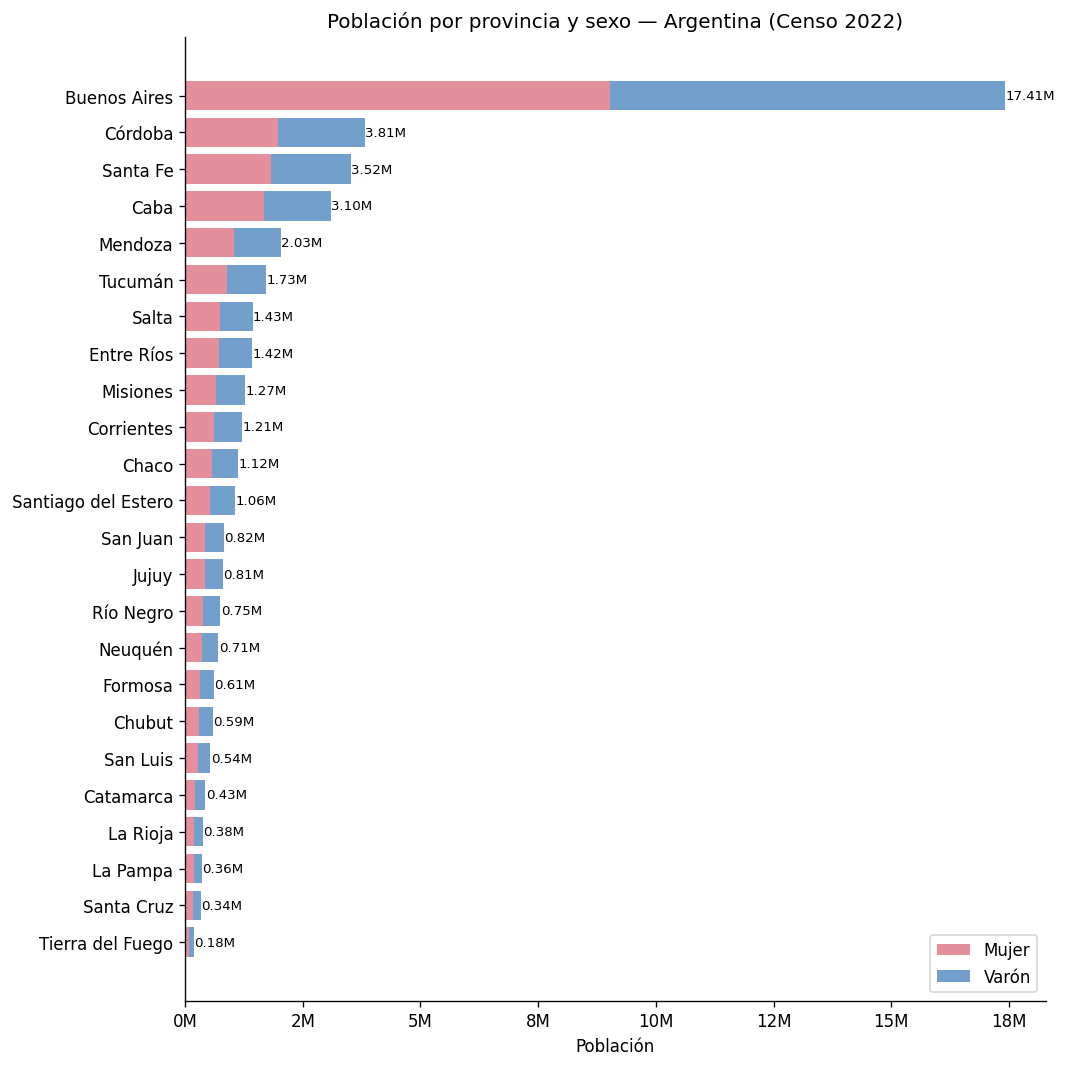

In [7]:
# Gráfico: población por provincia abierta por género
plot_df = sexo_prov[[CAT_MUJER, CAT_VARON]].sort_values("Total".replace("Total", CAT_MUJER), ascending=True)
plot_df = sexo_prov[[CAT_MUJER, CAT_VARON]].sort_values(CAT_MUJER, ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
y = range(len(plot_df))
ax.barh(list(y), plot_df[CAT_MUJER], color=MUJER, alpha=0.85, label="Mujer")
ax.barh(list(y), plot_df[CAT_VARON], left=plot_df[CAT_MUJER], color=VARON, alpha=0.85, label="Varón")

for i, (prov, row) in enumerate(plot_df.iterrows()):
    total = row[CAT_MUJER] + row[CAT_VARON]
    ax.text(total + 10_000, i, f"{total/1e6:.2f}M", va="center", fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Población")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_title("Población por provincia y sexo — Argentina (Censo 2022)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Pirámide poblacional

La pirámide muestra la distribución por grupos quinquenales de edad.
Como sexo y edad son variables independientes en la base, se presentan por separado.
La pirámide usa el total de cada grupo de edad.

In [8]:
# Tabla quinquenal nacional
quin_nac = (
    df_edad
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "grupo_edad", "conteo": "N"})
)
quin_nac["%"] = (quin_nac["N"] / quin_nac["N"].sum() * 100).round(2)
print("=== PIRÁMIDE NACIONAL ===")
print(quin_nac[["grupo_edad", "N", "%"]].to_string(index=False))

=== PIRÁMIDE NACIONAL ===
grupo_edad       N    %
   00 A 04 2843750 6.23
   45 A 49 2862951 6.28
   50 A 54 2448174 5.37
   55 A 59 2194131 4.81
   60 A 64 1977706 4.34
   65 A 69 1732554 3.80
   70 A 74 1415564 3.10
   75 A 79 1021910 2.24
   80 A 84  645505 1.41
   85 A 89  353619 0.78
   90 A 94  156156 0.34
   05 A 09 3596417 7.88
   95 A 99   42581 0.09
 100 A 104    4725 0.01
 105 Y MÁS     809 0.00
   10 A 14 3628906 7.95
   15 A 19 3559019 7.80
   20 A 24 3510461 7.70
   25 A 29 3550391 7.78
   30 A 34 3469534 7.61
   35 A 39 3288769 7.21
   40 A 44 3315155 7.27


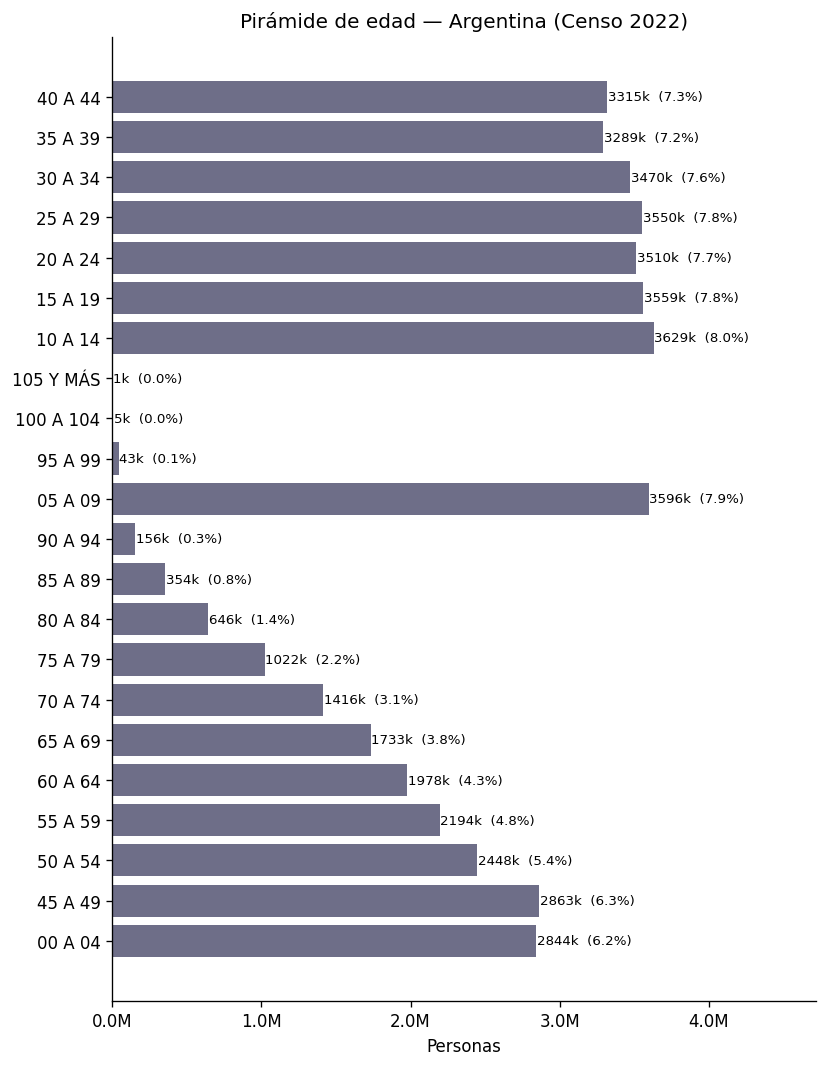

In [9]:
# Gráfico pirámide nacional
def graficar_piramide(quin_df, titulo):
    fig, ax = plt.subplots(figsize=(7, 9))
    y = range(len(quin_df))
    ax.barh(list(y), quin_df["N"], color=TOTAL, alpha=0.8)
    for i, (n, pct) in enumerate(zip(quin_df["N"], quin_df["%"])):
        ax.text(n + 5_000, i, f"{n/1e3:.0f}k  ({pct:.1f}%)",
                va="center", fontsize=8)
    ax.set_yticks(list(y))
    ax.set_yticklabels(quin_df["grupo_edad"])
    ax.set_xlabel("Personas")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    ax.set_xlim(0, quin_df["N"].max() * 1.3)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

graficar_piramide(quin_nac, "Pirámide de edad — Argentina (Censo 2022)")

In [10]:
# Pirámide por provincia — cambiá este valor
PROV_PIRAMIDE = "Córdoba"

df_edad_prov = censo.query(variables="PERSONA_EDADQUI", provincia=PROV_PIRAMIDE)

quin_prov = (
    df_edad_prov
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "grupo_edad", "conteo": "N"})
)
quin_prov["%"] = (quin_prov["N"] / quin_prov["N"].sum() * 100).round(2)

print(f"=== PIRÁMIDE: {PROV_PIRAMIDE} ===")
print(quin_prov[["grupo_edad", "N", "%"]].to_string(index=False))

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_EDADQUI
[ciut]   Provincia: Córdoba  (código INDEC: 14)
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde Hugging Face...
[ciut] Descarga completa en 0.7s -> 126,020 filas | 13 columnas | 79.7 MB en memoria
=== PIRÁMIDE: Córdoba ===
grupo_edad      N    %
   00 A 04 233437 6.12
   45 A 49 237816 6.24
   50 A 54 204847 5.37


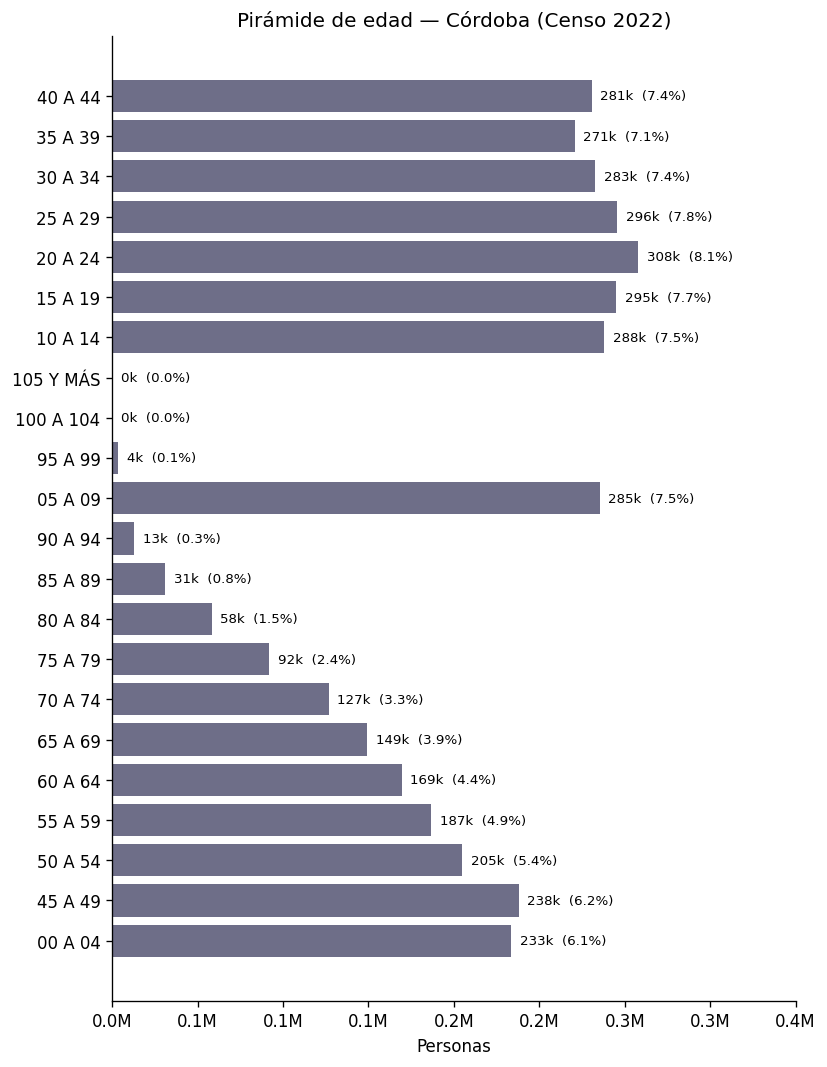

In [11]:
graficar_piramide(quin_prov, f"Pirámide de edad — {PROV_PIRAMIDE} (Censo 2022)")

In [12]:
# Tabla comparativa de estructura etaria por provincia
# (grandes grupos: 0-14, 15-64, 65+)
df_edadgru = censo.query(variables="PERSONA_EDADGRU")

edad_prov = (
    df_edadgru
    .groupby(["etiqueta_provincia", "valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .pivot_table(index="etiqueta_provincia", columns="etiqueta_categoria",
                 values="conteo", aggfunc="sum")
    .fillna(0).astype(int)
)
edad_prov.columns.name = None
edad_prov["Total"] = edad_prov.sum(axis=1)
# % por columna
for col in [c for c in edad_prov.columns if c != "Total"]:
    edad_prov[f"% {col[:6]}"] = (edad_prov[col] / edad_prov["Total"] * 100).round(1)
edad_prov.sort_values("Total", ascending=False)

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_EDADGRU
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde Hugging Face...
[ciut] Descarga completa en 0.4s -> 197,412 filas | 13 columnas | 127.0 MB en memoria


,15 A 64 AÑOS,65 AÑOS Y MÁS,HASTA 14 AÑOS,Total,% 15 A 6,% 65 AÑO,% HASTA
etiqueta_provincia,,,,,,,
Buenos Aires,11467152,2113084,3828670,17408906,65.9,12.1,22.0
Córdoba,2531392,474062,806610,3812064,66.4,12.4,21.2
Santa Fe,2324667,448446,745946,3519059,66.1,12.7,21.2
Caba,2098574,537004,459876,3095454,67.8,17.3,14.9
Mendoza,1311337,249972,469464,2030773,64.6,12.3,23.1
Tucumán,1144072,181495,401770,1727337,66.2,10.5,23.3
Salta,940893,130469,362863,1434225,65.6,9.1,25.3
Entre Ríos,931596,168796,314705,1415097,65.8,11.9,22.2
Misiones,827140,105246,340961,1273347,65.0,8.3,26.8


---
## 4. Nivel educativo — nacional y por provincia

In [13]:
# Categorías reales del nivel educativo
censo.describe("PERSONA_MNI")

[ciut] Consultando metadatos de 'PERSONA_MNI'...

  Variable   : PERSONA_MNI
  Nombre INDEC: MNI
  Descripción: Máximo nivel de instrucción alcanzado
  Entidad    : PERSONA  (aplica a personas)
  Referencia : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorías (12 valores):
  Código      Etiqueta
  --------  ----------------------------------------
  1           Sin instrucción
  2           Primario incompleto
  3           Primario completo
  4           Secundario incompleto
  5           Secundario completo
  6           Terciario incompleto
  7           Terciario completo
  8           Universitario incompleto
  9           Universitario completo
  10          Posgrado incompleto
  11          Posgrado completo
  99          Ignorado



In [14]:
# Tabla nacional de nivel educativo (excluye ignorado = código 99)
educ_nac = (
    df_educ[df_educ["valor_categoria"] != "99"]
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "nivel", "conteo": "N"})
)
educ_nac["%"] = (educ_nac["N"] / educ_nac["N"].sum() * 100).round(1)
print("=== NIVEL EDUCATIVO NACIONAL ===")
print(educ_nac[["nivel", "N", "%"]].to_string(index=False))

=== NIVEL EDUCATIVO NACIONAL ===
                   nivel       N    %
         Sin instrucción 4596243 10.1
     Posgrado incompleto  374427  0.8
       Posgrado completo  588234  1.3
     Primario incompleto 7146944 15.8
       Primario completo 5449199 12.0
   Secundario incompleto 9592664 21.1
     Secundario completo 7323124 16.1
    Terciario incompleto 2103710  4.6
      Terciario completo 2555570  5.6
Universitario incompleto 3460263  7.6
  Universitario completo 2170617  4.8


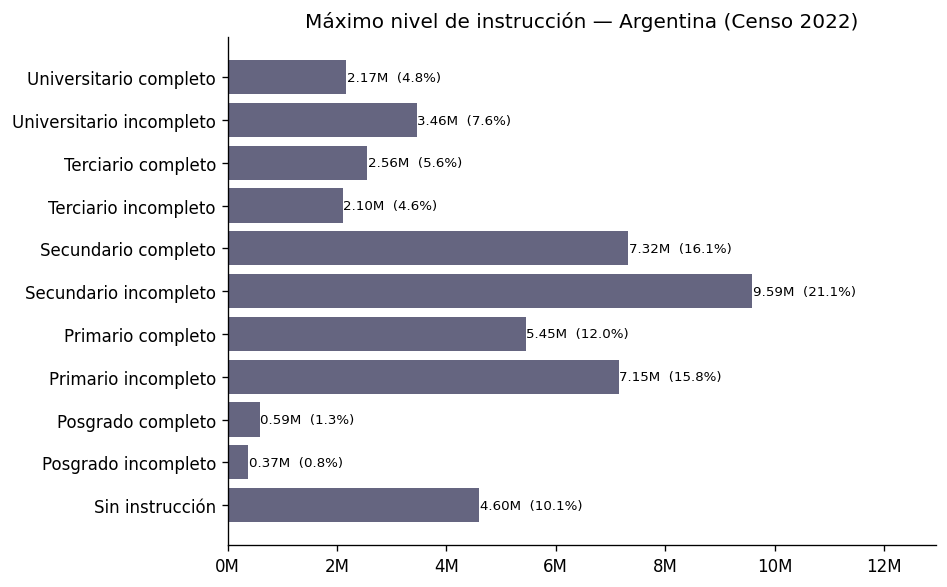

In [15]:
# Gráfico nacional
fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(educ_nac))
ax.barh(list(y), educ_nac["N"], color=TOTAL, alpha=0.85)

for i, (n, pct) in enumerate(zip(educ_nac["N"], educ_nac["%"])):
    ax.text(n + 10_000, i, f"{n/1e6:.2f}M  ({pct}%)",
            va="center", fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(educ_nac["nivel"])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_xlim(0, educ_nac["N"].max() * 1.35)
ax.set_title("Máximo nivel de instrucción — Argentina (Censo 2022)")
plt.tight_layout()
plt.show()

In [16]:
# Tabla por provincia (% de cada nivel)
educ_prov = (
    df_educ[df_educ["valor_categoria"] != "99"]
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum()
    .unstack("etiqueta_categoria")
    .fillna(0).astype(int)
)
educ_prov.columns.name = None
educ_prov["Total"] = educ_prov.sum(axis=1)
educ_prov_pct = educ_prov.drop(columns="Total").div(educ_prov["Total"], axis=0).mul(100).round(1)
educ_prov_pct.sort_values(educ_prov_pct.columns[-1], ascending=False)

,Posgrado completo,Posgrado incompleto,Primario completo,Primario incompleto,Secundario completo,Secundario incompleto,Sin instrucción,Terciario completo,Terciario incompleto,Universitario completo,Universitario incompleto
etiqueta_provincia,,,,,,,,,,,
Caba,4.8,2.4,5.5,9.4,15.3,13.7,7.2,8.2,5.4,13.7,14.4
La Rioja,0.8,0.8,11.3,16.1,17.6,18.4,9.9,5.5,5.2,3.8,10.4
San Luis,1.1,0.9,10.4,15.5,17.2,22.5,10.5,4.2,3.3,4.4,9.9
Córdoba,1.4,0.9,11.0,13.9,15.6,22.7,9.3,5.9,4.1,6.0,9.2
Tierra del Fuego,1.3,1.2,6.3,12.6,18.9,22.9,11.2,6.1,7.0,4.5,8.0
Río Negro,1.3,0.8,11.6,17.2,14.3,22.3,9.8,5.6,4.8,4.8,7.7
San Juan,1.0,0.7,13.7,16.1,13.7,23.1,11.7,4.4,3.7,4.2,7.7
Tucumán,1.0,0.7,14.5,16.1,14.4,21.0,11.4,4.6,5.0,3.6,7.6
Buenos Aires,1.1,0.7,12.6,14.6,17.9,22.3,9.7,5.4,4.1,4.2,7.5


[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_MNI
[ciut]   Provincia: Buenos Aires  (código INDEC: 06)
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde Hugging Face...
[ciut] Descarga completa en 0.5s -> 264,568 filas | 13 columnas | 166.8 MB en memoria
[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut]

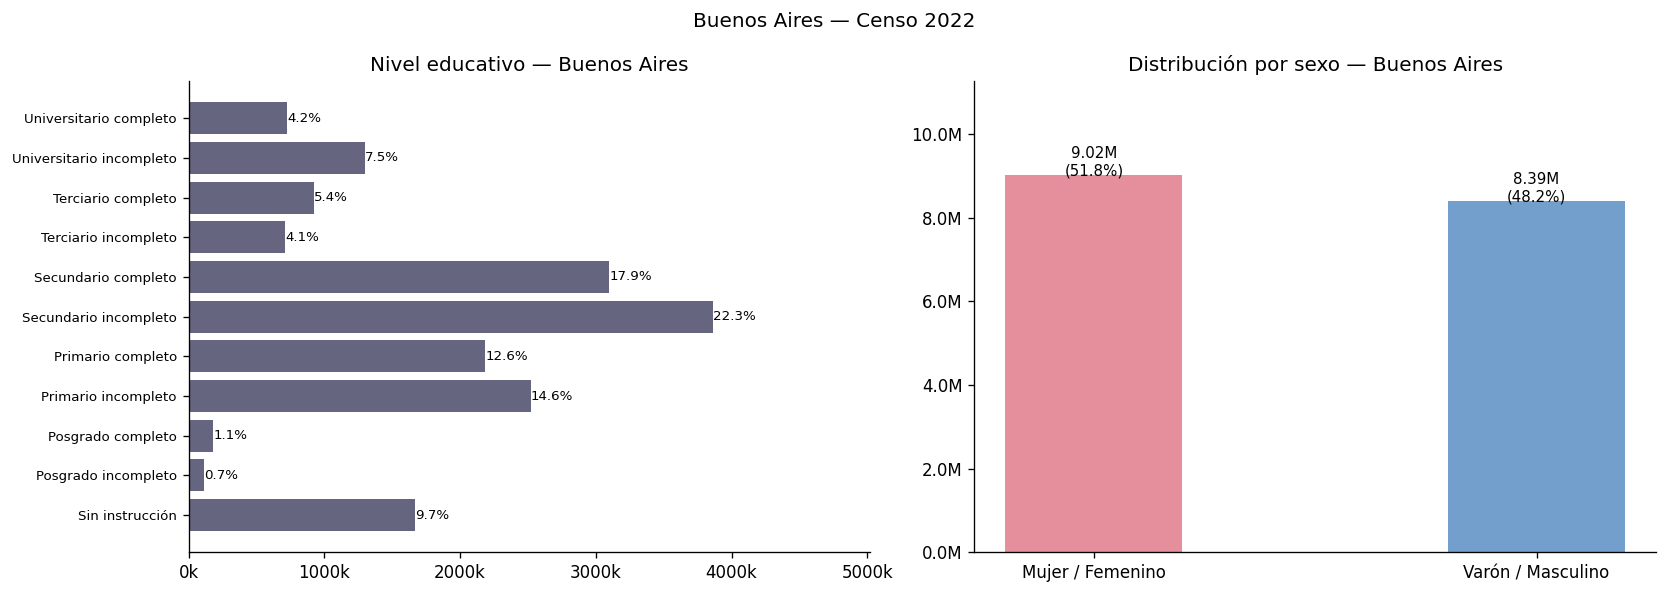

In [17]:
# Nivel educativo por provincia — apertura por sexo (distribuciones paralelas)
PROV_EDUC = "Buenos Aires"  # Cambiá esta provincia

df_educ_p = censo.query(variables="PERSONA_MNI",  provincia=PROV_EDUC)
df_sexo_p = censo.query(variables="PERSONA_P02",  provincia=PROV_EDUC)

educ_p = (
    df_educ_p[df_educ_p["valor_categoria"] != "99"]
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "nivel", "conteo": "N"})
)
educ_p["%"] = (educ_p["N"] / educ_p["N"].sum() * 100).round(1)

sexo_p = (
    df_sexo_p
    .groupby("etiqueta_categoria")["conteo"]
    .sum().reset_index()
    .rename(columns={"etiqueta_categoria": "sexo", "conteo": "N"})
)
sexo_p["%"] = (sexo_p["N"] / sexo_p["N"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Educación
axes[0].barh(range(len(educ_p)), educ_p["N"], color=TOTAL, alpha=0.85)
axes[0].set_yticks(range(len(educ_p)))
axes[0].set_yticklabels(educ_p["nivel"], fontsize=8)
for i, (n, pct) in enumerate(zip(educ_p["N"], educ_p["%"])):
    axes[0].text(n + 500, i, f"{pct}%", va="center", fontsize=8)
axes[0].set_title(f"Nivel educativo — {PROV_EDUC}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[0].set_xlim(0, educ_p["N"].max() * 1.3)

# Sexo
axes[1].bar(sexo_p["sexo"], sexo_p["N"], color=[MUJER, VARON], alpha=0.85, width=0.4)
for i, (n, pct) in enumerate(zip(sexo_p["N"], sexo_p["%"])):
    axes[1].text(i, n + 1000, f"{n/1e6:.2f}M\n({pct}%)",
                 ha="center", fontsize=9)
axes[1].set_title(f"Distribución por sexo — {PROV_EDUC}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].set_ylim(0, sexo_p["N"].max() * 1.25)

plt.suptitle(f"{PROV_EDUC} — Censo 2022", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Déficit habitacional — NBI Total

In [18]:
censo.describe("HOGAR_NBI_TOT")

[ciut] Consultando metadatos de 'HOGAR_NBI_TOT'...

  Variable   : HOGAR_NBI_TOT
  Nombre INDEC: NBI_TOT
  Descripción: Necesidades básicas insatisfechas
  Entidad    : HOGAR  (aplica a hogares)
  Referencia : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorías (2 valores):
  Código      Etiqueta
  --------  ----------------------------------------
  1           Sí
  2           No



In [19]:
# NBI total nacional
nbi_nac = tabla_n_pct(
    df_nbi_tot.groupby("etiqueta_categoria")["conteo"].sum(), HOGAR_TOTAL
)
nbi_nac.columns = ["categoria", "N", "%"]
print("=== NBI TOTAL NACIONAL ===")
print(nbi_nac.to_string(index=False))

=== NBI TOTAL NACIONAL ===
categoria        N    %
       No 14858011 93.3
       Sí  1074291  6.7


In [20]:
# Tabla NBI por provincia (N y %)
nbi_prov = (
    df_nbi_tot
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum().unstack("etiqueta_categoria")
    .fillna(0).astype(int)
)
nbi_prov.columns.name = None
nbi_prov["Total hogares"] = nbi_prov.sum(axis=1)

# Columna con NBI (la que no dice "sin")
col_con_nbi = [c for c in nbi_prov.columns if "Sin" not in c and "Total" not in c][0]
col_sin_nbi = [c for c in nbi_prov.columns if "Sin" in c][0]

nbi_prov["% con NBI"] = (nbi_prov[col_con_nbi] / nbi_prov["Total hogares"] * 100).round(1)
nbi_prov = nbi_prov.sort_values("% con NBI", ascending=False)
nbi_prov

IndexError: list index out of range

In [ ]:
# Gráfico NBI por provincia
plot_nbi = nbi_prov[["% con NBI"]].sort_values("% con NBI")

fig, ax = plt.subplots(figsize=(8, 8))
colores_nbi = [NARANJA if v > plot_nbi["% con NBI"].mean() else VERDE
               for v in plot_nbi["% con NBI"]]
ax.barh(plot_nbi.index, plot_nbi["% con NBI"], color=colores_nbi, alpha=0.85)
ax.axvline(plot_nbi["% con NBI"].mean(), color="grey", linestyle="--",
           linewidth=0.9, label=f"Promedio: {plot_nbi['% con NBI'].mean():.1f}%")

for prov, val in plot_nbi["% con NBI"].items():
    ax.text(val + 0.2, list(plot_nbi.index).index(prov), f"{val}%",
            va="center", fontsize=8)

ax.set_xlabel("% hogares con NBI")
ax.set_title("Hogares con NBI por provincia — Argentina (Censo 2022)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Componentes del NBI

In [21]:
# Resumen de los 5 componentes — nacional
nbi_vars = {
    "NBI Escolaridad"    : df_nbi_esc,
    "NBI Hacinamiento"   : df_nbi_hac,
    "NBI Saneamiento"    : df_nbi_san,
    "NBI Subsistencia"   : df_nbi_sub,
    "NBI Vivienda"       : df_nbi_viv,
}

def pct_con_nbi(df):
    """Extrae el % de hogares con NBI de un df de variable binaria."""
    resumen = df.groupby("etiqueta_categoria")["conteo"].sum()
    total = resumen.sum()
    col_nbi = [c for c in resumen.index if "Sin" not in c][0]
    n_nbi   = resumen[col_nbi]
    return n_nbi, total, round(n_nbi / total * 100, 1)

filas = []
for nombre, df in nbi_vars.items():
    n, t, pct = pct_con_nbi(df)
    filas.append({"Componente": nombre, "N hogares con NBI": n,
                  "Total hogares": t, "% con NBI": pct})

resumen_nbi = pd.DataFrame(filas).sort_values("% con NBI", ascending=False)
print("=== COMPONENTES NBI NACIONAL ===")
print(resumen_nbi.to_string(index=False))

=== COMPONENTES NBI NACIONAL ===
      Componente  N hogares con NBI  Total hogares  % con NBI
NBI Subsistencia           15844971       15932302       99.5
 NBI Escolaridad           15805216       15932302       99.2
 NBI Saneamiento           15804310       15932302       99.2
NBI Hacinamiento           15519812       15932302       97.4
    NBI Vivienda           15490469       15932302       97.2


In [ ]:
# Gráfico componentes
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(resumen_nbi["Componente"], resumen_nbi["% con NBI"],
        color=NARANJA, alpha=0.85)

for i, (n, pct) in enumerate(zip(resumen_nbi["N hogares con NBI"], resumen_nbi["% con NBI"])):
    ax.text(pct + 0.1, i, f"{pct}%  ({n/1e3:.0f}k hogares)",
            va="center", fontsize=9)

ax.set_xlabel("% hogares afectados")
ax.set_xlim(0, resumen_nbi["% con NBI"].max() * 1.5)
ax.set_title("Componentes NBI — Argentina (Censo 2022)")
plt.tight_layout()
plt.show()

In [22]:
# Componentes NBI por provincia
def nbi_por_provincia(df):
    prov = (
        df.groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
        .sum().unstack().fillna(0).astype(int)
    )
    prov.columns.name = None
    total = prov.sum(axis=1)
    col_nbi = [c for c in prov.columns if "Sin" not in c][0]
    return (prov[col_nbi] / total * 100).round(1)

tabla_comp = pd.DataFrame({
    nombre: nbi_por_provincia(df)
    for nombre, df in nbi_vars.items()
})
tabla_comp["NBI Total"] = nbi_prov["% con NBI"]
tabla_comp.sort_values("NBI Total", ascending=False)

KeyError: '% con NBI'

---
## 7. Hacinamiento de hogares

In [23]:
censo.describe("HOGAR_H20CP")

[ciut] Consultando metadatos de 'HOGAR_H20CP'...

  Variable   : HOGAR_H20CP
  Nombre INDEC: H20CP
  Descripción: Hacinamiento del hogar
  Entidad    : HOGAR  (aplica a hogares)
  Referencia : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorías (6 valores):
  Código      Etiqueta
  --------  ----------------------------------------
  1           Hasta   0.50  personas por cuarto
  2           0.51  -  0.99  personas por cuarto
  3           1.00  -  1.49  personas por cuarto
  4           1.50  -  1.99  personas por cuarto
  5           2.00  -  3.00  personas por cuarto
  6           Más de 3.00  personas por cuarto



In [24]:
# Hacinamiento nacional
hacin_nac = (
    df_hacin
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "categoria", "conteo": "N"})
)
hacin_nac["%"] = (hacin_nac["N"] / hacin_nac["N"].sum() * 100).round(1)
print("=== HACINAMIENTO NACIONAL ===")
print(hacin_nac[["categoria", "N", "%"]].to_string(index=False))

=== HACINAMIENTO NACIONAL ===
                         categoria       N    %
 Hasta   0.50  personas por cuarto 4617066 29.0
0.51  -  0.99  personas por cuarto 2623052 16.5
1.00  -  1.49  personas por cuarto 4880056 30.6
1.50  -  1.99  personas por cuarto 1424971  8.9
2.00  -  3.00  personas por cuarto 1974667 12.4
  Más de 3.00  personas por cuarto  412490  2.6


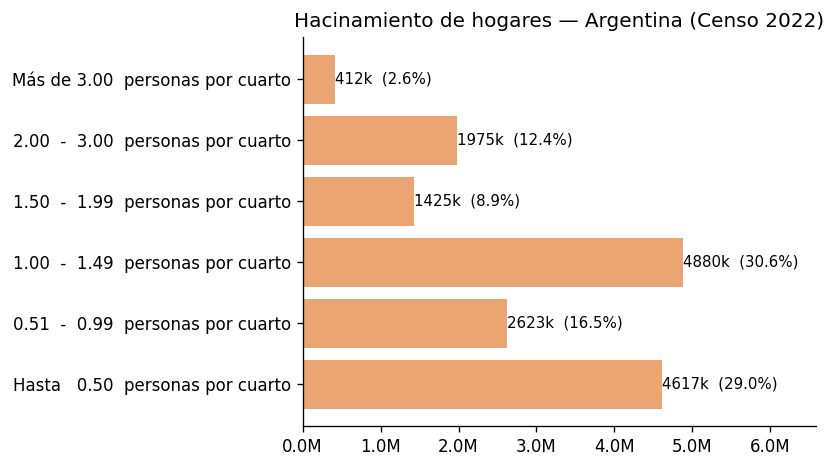

In [25]:
# Gráfico hacinamiento
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(hacin_nac)), hacin_nac["N"],
        color=[VERDE if "Sin" in c else NARANJA for c in hacin_nac["categoria"]],
        alpha=0.85)
ax.set_yticks(range(len(hacin_nac)))
ax.set_yticklabels(hacin_nac["categoria"])
for i, (n, pct) in enumerate(zip(hacin_nac["N"], hacin_nac["%"])):
    ax.text(n + 500, i, f"{n/1e3:.0f}k  ({pct}%)",
            va="center", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlim(0, hacin_nac["N"].max() * 1.35)
ax.set_title("Hacinamiento de hogares — Argentina (Censo 2022)")
plt.tight_layout()
plt.show()

In [26]:
# Hacinamiento por provincia
hacin_prov = (
    df_hacin
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum().unstack().fillna(0).astype(int)
)
hacin_prov.columns.name = None
hacin_prov["Total"] = hacin_prov.sum(axis=1)
col_hac = [c for c in hacin_prov.columns if "Sin" not in c and "Total" not in c]
hacin_prov["% con hacinamiento"] = (
    hacin_prov[col_hac].sum(axis=1) / hacin_prov["Total"] * 100
).round(1)
hacin_prov.sort_values("% con hacinamiento", ascending=False)

,0.51 - 0.99 personas por cuarto,1.00 - 1.49 personas por cuarto,1.50 - 1.99 personas por cuarto,2.00 - 3.00 personas por cuarto,Hasta 0.50 personas por cuarto,Más de 3.00 personas por cuarto,Total,% con hacinamiento
etiqueta_provincia,,,,,,,,
Buenos Aires,999734,1889348,556711,765311,1685351,155095,6051550,100.0
Caba,224110,447986,69862,103613,547098,14066,1406735,100.0
Catamarca,21865,40110,14563,19172,35712,3731,135153,100.0
Chaco,56432,115491,40080,55714,93598,13172,374487,100.0
Chubut,36039,66489,17476,25503,64820,4930,215257,100.0
Corrientes,55877,115490,41312,61694,88543,16213,379129,100.0
Córdoba,237173,397707,111312,154406,464114,29688,1394400,100.0
Entre Ríos,83755,150363,45900,61006,148170,11466,500660,100.0
Formosa,26833,60970,21132,34276,44855,10140,198206,100.0


---
## 8. Índice de Privación Material de los Hogares (IPMH)

In [27]:
censo.describe("HOGAR_IPMH")

[ciut] Consultando metadatos de 'HOGAR_IPMH'...

  Variable   : HOGAR_IPMH
  Nombre INDEC: IPMH
  Descripción: Indice de privación material de los hogares
  Entidad    : HOGAR  (aplica a hogares)
  Referencia : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorías (4 valores):
  Código      Etiqueta
  --------  ----------------------------------------
  1           Sin privación
  2           Privación solo de recursos corrientes
  3           Privación solo recursos patrimoniales
  4           Privación Convergente



In [28]:
# IPMH nacional
ipmh_nac = (
    df_ipmh
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "categoria", "conteo": "N"})
)
ipmh_nac["%"] = (ipmh_nac["N"] / ipmh_nac["N"].sum() * 100).round(1)
print("=== IPMH NACIONAL ===")
print(ipmh_nac[["categoria", "N", "%"]].to_string(index=False))

=== IPMH NACIONAL ===
                            categoria        N    %
                        Sin privación 10438909 65.5
Privación solo de recursos corrientes  2541233 16.0
Privación solo recursos patrimoniales  1629074 10.2
                Privación Convergente  1323086  8.3


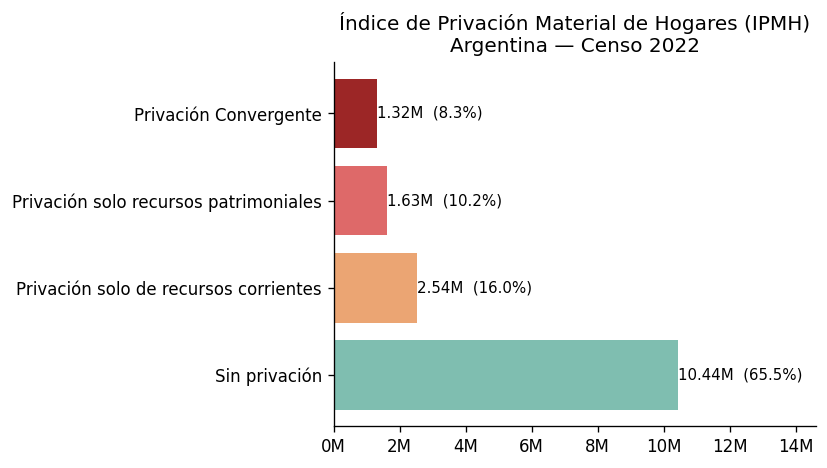

In [29]:
# Gráfico IPMH
fig, ax = plt.subplots(figsize=(7, 4))
colores_ipmh = [VERDE, NARANJA, "#d94f4f", "#8B0000"]
ax.barh(range(len(ipmh_nac)), ipmh_nac["N"],
        color=colores_ipmh[:len(ipmh_nac)], alpha=0.85)
ax.set_yticks(range(len(ipmh_nac)))
ax.set_yticklabels(ipmh_nac["categoria"])
for i, (n, pct) in enumerate(zip(ipmh_nac["N"], ipmh_nac["%"])):
    ax.text(n + 500, i, f"{n/1e6:.2f}M  ({pct}%)",
            va="center", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_xlim(0, ipmh_nac["N"].max() * 1.4)
ax.set_title("Índice de Privación Material de Hogares (IPMH)\nArgentina — Censo 2022")
plt.tight_layout()
plt.show()

In [30]:
# IPMH por provincia
ipmh_prov = (
    df_ipmh
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum().unstack().fillna(0).astype(int)
)
ipmh_prov.columns.name = None
ipmh_prov["Total"] = ipmh_prov.sum(axis=1)
for col in [c for c in ipmh_prov.columns if c != "Total"]:
    ipmh_prov[f"% {col[:15]}"] = (ipmh_prov[col] / ipmh_prov["Total"] * 100).round(1)
ipmh_prov.sort_values("Total", ascending=False)

,Privación Convergente,Privación solo de recursos corrientes,Privación solo recursos patrimoniales,Sin privación,Total,% Privación Conve,% Privación solo,% Sin privación
etiqueta_provincia,,,,,,,,
Buenos Aires,460940,896204,662067,4032339,6051550,7.6,10.9,66.6
Caba,15814,145126,37617,1208178,1406735,1.1,2.7,85.9
Córdoba,53227,252850,71124,1017199,1394400,3.8,5.1,72.9
Santa Fe,108658,192106,121701,867502,1289967,8.4,9.4,67.2
Mendoza,52804,131139,59074,409167,652184,8.1,9.1,62.7
Tucumán,84582,76888,89915,254157,505542,16.7,17.8,50.3
Entre Ríos,38637,92572,40778,328673,500660,7.7,8.1,65.6
Misiones,53156,97540,40438,234533,425667,12.5,9.5,55.1
Salta,80669,55865,88716,193180,418430,19.3,21.2,46.2


---
## 9. Resumen déficit habitacional por provincia

In [31]:
# Tabla resumen de todos los indicadores de deficit
deficit = pd.DataFrame(index=nbi_prov.index)
deficit["% NBI Total"]       = nbi_prov["% con NBI"]
deficit["% NBI Escolaridad"] = nbi_por_provincia(df_nbi_esc)
deficit["% NBI Hacinamiento"]= nbi_por_provincia(df_nbi_hac)
deficit["% NBI Saneamiento"] = nbi_por_provincia(df_nbi_san)
deficit["% NBI Subsistencia"]= nbi_por_provincia(df_nbi_sub)
deficit["% NBI Vivienda"]    = nbi_por_provincia(df_nbi_viv)
deficit["% Hacinamiento"]    = hacin_prov["% con hacinamiento"]

deficit.sort_values("% NBI Total", ascending=False)

KeyError: '% con NBI'

In [ ]:
# Heatmap de déficit por provincia
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 9))
data = deficit.sort_values("% NBI Total", ascending=False)

im = ax.imshow(data.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index, fontsize=9)

for i in range(len(data.index)):
    for j in range(len(data.columns)):
        val = data.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                    fontsize=7, color="black" if val < 15 else "white")

plt.colorbar(im, ax=ax, label="%")
ax.set_title("Indicadores de déficit habitacional por provincia — Censo 2022")
plt.tight_layout()
plt.show()

---
## 10. Exportar

In [32]:
with pd.ExcelWriter("analisis_censal_2022.xlsx") as writer:
    sexo_prov.to_excel(writer, sheet_name="Poblacion_sexo")
    edad_prov.to_excel(writer, sheet_name="Grupos_edad")
    educ_prov.to_excel(writer, sheet_name="Nivel_educativo")
    nbi_prov.to_excel(writer, sheet_name="NBI_total")
    tabla_comp.to_excel(writer, sheet_name="NBI_componentes")
    hacin_prov.to_excel(writer, sheet_name="Hacinamiento")
    ipmh_prov.to_excel(writer, sheet_name="IPMH")
    deficit.to_excel(writer, sheet_name="Deficit_resumen")

print("Exportado: analisis_censal_2022.xlsx")

ModuleNotFoundError: No module named 'openpyxl'